<a href="https://colab.research.google.com/github/laurenesgarcianatalia-rgb/metodos-/blob/main/M%C3%89TODODEBISECCI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MÉTODO DE BISECCIÓN

Queremos resolver el problema de la búsqueda de raíces de la ecuación $f(x)=0$.

Por definición una *raiz* o *cero* de la ecuación es un número*p*, tal que $f(p)=0$

**Ejemplo 1** *(Burden, p.38)*
Se quiere resolver la ecuacion $x^3+4x^2-10=0$ en el intervalo inicial $[1,2]$

Según las indicaciones el algoritmo debe detenerse cuando la cota de error relativo sea menor a $10^{-4}$ (es decir, una tolerancia $TOL = 0.0001$).

EL *método de bisección* consiste en dividir a la mitad el intervalo en cada iteración. El punto medio Pn es la solución aproximada.

In [5]:
from math import *
import numpy as np
import matplotlib.pyplot as plt #para la grafica
import pandas as pd #para la tabla

In [6]:
# 1. definiendo la ecuación del ejemplo
def f(x):
  return x**3 + 4*x**2 - 10.0

In [13]:
#2. Para aplicar el método de bisección, primero verificamos que la función cambie de signo en los extremos del intervalo. (y comprobando que la función este bien definida)
f(1)

-5.0

In [12]:
f(2)

14.0

2.Calculamos los valores en los extremos:

$f(1)=-5$

$f(2)=14$

Como:
$f(1)f(2)<0$
existe al menos una raíz dentro del intervalo $[1,2]$.

El método de bisección consiste en dividir el intervalo en dos partes
y conservar el subintervalo donde se mantiene el cambio de signo.

En cada iteración se calcula el punto medio

$$
p=a+\frac{b-a}{2}.
$$

Después se evalúa la función en $p$ y se verifica si se cumple el
criterio de tolerancia.

El proceso continúa hasta encontrar una aproximación que cumpla con
la tolerancia establecida o hasta alcanzar el número máximo de
iteraciones.

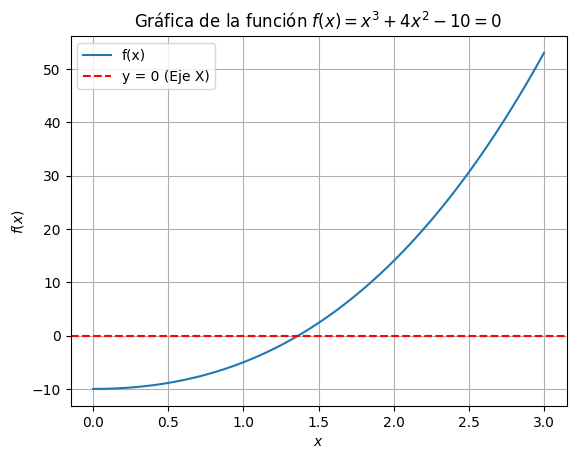

In [9]:
# 3. análisis gráfico
x = np.linspace(0,3,100) #genera una reticula o una particion de 100 puntos entre 0 y 3 para visualizar el cruce por cero
plt.plot(x, f(x), label="f(x)")
plt.title("Gráfica de la función $f(x) = x^3 + 4x^2 - 10 = 0$") #titulo
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.axhline(y=0, color='red', linestyle='--', label='y = 0 (Eje X)') # Dibuja la línea del eje X
plt.legend() #muestra la informacion de las rayas de colores
plt.grid(True) #activa la cuadricula
plt.show() #renderiza y uestra la imagen final

#3. Implementación del algoritmo 2.1
Se programa el ciclo iterativo siguiendo los pasos detallados en el diagrama del método. Se utilizará la librería `pandas` para almacenar los datos de cada iteración y presentarlos de forma limpia en una tabla.

In [22]:
#ingreso datos de entrada para los diferentes metodos a trabajar
a = 1
b = 2
#guardar valores iniciales del intervalo
a0 = a
b0 = b
#tolerancia y número máximo de iteraciones
tol = 0.00001
N0 = 100

#valore inicial de f(a)
FA = f(a)

#Contador de iteraciones
i=1

# Variable para saber si el procedimiento fue exitoso
exito = False

#Lista para guardar los resultados de cada iteraciób
iteraciones = []

#Metodo de bisección

#ciclo iterativo
while i <= N0: #porque el paso 2 de Burden dice mientras i<=N0
  # calcular el punto medio
  m = a + (b-a) /2
  #evaluar la funcion en el punto medio
  fm=f(m)
# Calcular el error actual (mitad de la longitud del intervalo)
  error = abs((b - a) / 2.0)
# Guardar los valores de la iteración
  iteraciones.append([i, a, FA, b, f(b), m, fm, error])

# Paso 4: verificar el criterio de parada
  if fm == 0 or abs((b - a) / 2) < tol:
        solucion = m
        exito = True
        break # Detiene el ciclo si se alcanza la precisión
# Paso 5: aumentar el número de iteración
  i = i + 1

# Paso 6: determinar el nuevo intervalo
  if FA * fm > 0:
        a = m
        FA = fm
  else:
        b = m
# 3. Presentación de Resultados
# Creamos un DataFrame para mostrar los datos en una tabla ordenada
columnas = ['Iteración', 'a', 'f(a)', 'b', 'f(b)', 'Punto Medio (m)', 'f(m)', 'Error']
df_resultados = pd.DataFrame(iteraciones, columns=columnas)

# Mostramos la tabla
print("TABLA DE ITERACIONES - MÉTODO DE BISECCIÓN:")
display(df_resultados)

# Conclusión para identificar la solución final claramente
if exito:
    print(f"PROCEDIMIENTO COMPLETADO EXITOSAMENTE.")
    print(f"La raíz aproximada final es: {solucion:.5f}")
    print(f"Se alcanzó en la iteración {len(iteraciones)} con un error de {error:.6f}")
else:
    print(f" EL MÉTODO FRACASÓ.")
    print(f"No se alcanzó la tolerancia después de {N0} iteraciones.")

TABLA DE ITERACIONES - MÉTODO DE BISECCIÓN:


,Iteración,a,f(a),b,f(b),Punto Medio (m),f(m),Error
0,1,1.000000,-5.000000,2.000000,14.000000,1.500000,2.375000,0.500000
1,2,1.000000,-5.000000,1.500000,2.375000,1.250000,-1.796875,0.250000
2,3,1.250000,-1.796875,1.500000,2.375000,1.375000,0.162109,0.125000
3,4,1.250000,-1.796875,1.375000,0.162109,1.312500,-0.848389,0.062500
4,5,1.312500,-0.848389,1.375000,0.162109,1.343750,-0.350983,0.031250
5,6,1.343750,-0.350983,1.375000,0.162109,1.359375,-0.096409,0.015625
6,7,1.359375,-0.096409,1.375000,0.162109,1.367188,0.032356,0.007812
7,8,1.359375,-0.096409,1.367188,0.032356,1.363281,-0.032150,0.003906
8,9,1.363281,-0.032150,1.367188,0.032356,1.365234,0.000072,0.001953
9,10,1.363281,-0.032150,1.365234,0.000072,1.364258,-0.016047,0.000977


 PROCEDIMIENTO COMPLETADO EXITOSAMENTE.
La raíz aproximada final es: 1.36523
Se alcanzó en la iteración 17 con un error de 0.000008
